<a href="https://colab.research.google.com/github/deartoms/python/blob/main/Chapter04_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/bigdata/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic') # matplotlib 기본 폰트로 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.sans-serif'] = ['NanumGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ", plt.rcParams['font.family']) # 현재 적용된 폰트 이름 출력

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 폰트:  ['NanumGothic']


### 앙상블 학습 - 보팅 분류기 (Voting Classifier)

In [11]:
'/content/drive/MyDrive/kwu/ML/data/Breast_Cancer.csv'

'/content/drive/MyDrive/kwu/ML/data/Breast_Cancer.csv'

In [12]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import VotingClassifier # 앙상블 학습 기법 중 하나
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델
from sklearn.neighbors import KNeighborsClassifier # K-최근접 이웃 분류 모델
from sklearn.datasets import load_breast_cancer # 유방암 데이터셋
from sklearn.model_selection import train_test_split # 데이터셋을 훈련 세트와 테스트 세트로 분할
from sklearn.metrics import accuracy_score # 모델의 정확도를 평가

In [13]:
cancer = load_breast_cancer()

In [14]:
data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
print('피처 수:', data_df.shape[1])
data_df.head(3)

피처 수: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [16]:
# 소프트 보팅 기반 앙상블 구성
lr_clf = LogisticRegression(solver='liblinear', random_state=156) # 로지스틱 회귀 분류기 객체
knn_clf = KNeighborsClassifier(n_neighbors=8) # K-최근접 이웃 분류기 객체

vo_clf = VotingClassifier( # VotingClassifier 객체
    estimators=[('LR', lr_clf), ('KNN', knn_clf)], # 앙상블에 사용할 개별 모델 리스트
    voting='soft' # 보팅 방식
)

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=156)

# 보팅 앙상블 학습/평가
vo_clf.fit(X_train, y_train) # 앙상블 모델을 학습
pred = vo_clf.predict(X_test) # 학습된 보팅 분류기를 사용하여 예측을 수행
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

# 개별 모델 성능과 비교
print('\n[개별 모델 성능 비교]')
for clf in [lr_clf, knn_clf]:
  clf.fit(X_train, y_train)
  pred = clf.predict(X_test)
  print(f'{clf.__class__.__name__}: {accuracy_score(y_test, pred):.4f}')

Voting 분류기 정확도: 0.9561

[개별 모델 성능 비교]
LogisticRegression: 0.9474
KNeighborsClassifier: 0.9386


### 랜덤 포레스트 (Random Forest)

In [ ]:
# 사용자 행동 인식 데이터로 실습
# 'https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones'

In [17]:
import numpy as np
# 중복 컬럼
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df = pd.DataFrame(
      data=old_feature_name_df.groupby('column_name').cumcount(), #각 그룹 내에서 중복 횟수를 카운트
      columns=['dup_cnt'] # 중복 횟수 컬럼의 이름
  )
  feature_dup_df = feature_dup_df.reset_index()
  new_feature_name_df = pd.merge(old_feature_name_df.reset_index(),feature_dup_df, how='outer')
  # 중복 횟수가 0보다 크면 '원래이름_중복횟수', 아니면 '원래이름'
  new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(
      lambda x: x[0]+'_'+str(x[1]) if x[1] > 0 else x[0], axis=1
  )
  new_feature_name_df = new_feature_name_df.drop(['index'], axis=1) # 컬럼 삭제
  return new_feature_name_df

In [20]:
# UCI 사용자 행동 인식 데이터셋을 로드하고 반환하는 함수
# def get_human_dataset():
feature_name_df = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/features.txt', sep='\s+',
                                header=None, names=['column_index', 'column_name'])
feature_name_df

,column_index,column_name
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y
...,...,...
556,557,"angle(tBodyGyroMean,gravityMean)"
557,558,"angle(tBodyGyroJerkMean,gravityMean)"
558,559,"angle(X,gravityMean)"
559,560,"angle(Y,gravityMean)"


In [24]:
new_feature_name_df = pd.merge(feature_name_df.reset_index(),feature_dup_df, how='outer')
# 중복 횟수가 0보다 크면 '원래이름_중복횟수', 아니면 '원래이름'
new_feature_name_df['column_name'] = new_feature_name_df[['column_name','dup_cnt']].apply(
  lambda x: x[0]+'_'+str(x[1]) if x[1] > 0 else x[0], axis=1
)
new_feature_name_df = new_feature_name_df.drop(['index'], axis=1) # 컬럼 삭제
new_feature_name_df

SyntaxError: invalid non-printable character U+00A0 (706915416.py, line 4)

In [22]:
feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
feature_name

['tBodyAcc-mean()-X',
 'tBodyAcc-mean()-Y',
 'tBodyAcc-mean()-Z',
 'tBodyAcc-std()-X',
 'tBodyAcc-std()-Y',
 'tBodyAcc-std()-Z',
 'tBodyAcc-mad()-X',
 'tBodyAcc-mad()-Y',
 'tBodyAcc-mad()-Z',
 'tBodyAcc-max()-X',
 'tBodyAcc-max()-Y',
 'tBodyAcc-max()-Z',
 'tBodyAcc-min()-X',
 'tBodyAcc-min()-Y',
 'tBodyAcc-min()-Z',
 'tBodyAcc-sma()',
 'tBodyAcc-energy()-X',
 'tBodyAcc-energy()-Y',
 'tBodyAcc-energy()-Z',
 'tBodyAcc-iqr()-X',
 'tBodyAcc-iqr()-Y',
 'tBodyAcc-iqr()-Z',
 'tBodyAcc-entropy()-X',
 'tBodyAcc-entropy()-Y',
 'tBodyAcc-entropy()-Z',
 'tBodyAcc-arCoeff()-X,1',
 'tBodyAcc-arCoeff()-X,2',
 'tBodyAcc-arCoeff()-X,3',
 'tBodyAcc-arCoeff()-X,4',
 'tBodyAcc-arCoeff()-Y,1',
 'tBodyAcc-arCoeff()-Y,2',
 'tBodyAcc-arCoeff()-Y,3',
 'tBodyAcc-arCoeff()-Y,4',
 'tBodyAcc-arCoeff()-Z,1',
 'tBodyAcc-arCoeff()-Z,2',
 'tBodyAcc-arCoeff()-Z,3',
 'tBodyAcc-arCoeff()-Z,4',
 'tBodyAcc-correlation()-X,Y',
 'tBodyAcc-correlation()-X,Z',
 'tBodyAcc-correlation()-Y,Z',
 'tGravityAcc-mean()-X',
 'tGravityA

In [25]:
# 학습/테스트 피처 데이터 (sep=공백, 컬럼명 적용)
X_train = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/train/X_train.txt',
                      sep='\s+', names=feature_name)
X_test = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/test/X_test.txt',
                     sep='\s+', names=feature_name)

# 학습/테스트 레이블 (행동 종류: 1-6)
y_train = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/train/y_train.txt',
                      sep='\s+', header=None, names=['action'])
y_test = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/test/y_test.txt',
                     sep='\s+',header=None, names=['action'])

In [26]:
print('학습셋:', X_train.shape, '테스트셋:', X_test.shape)

학습셋: (7352, 561) 테스트셋: (2947, 561)


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 기본 랜덤 포레스트 학습
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
print('랜덤 포레스트 기본 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

랜덤 포레스트 기본 정확도: 0.9223


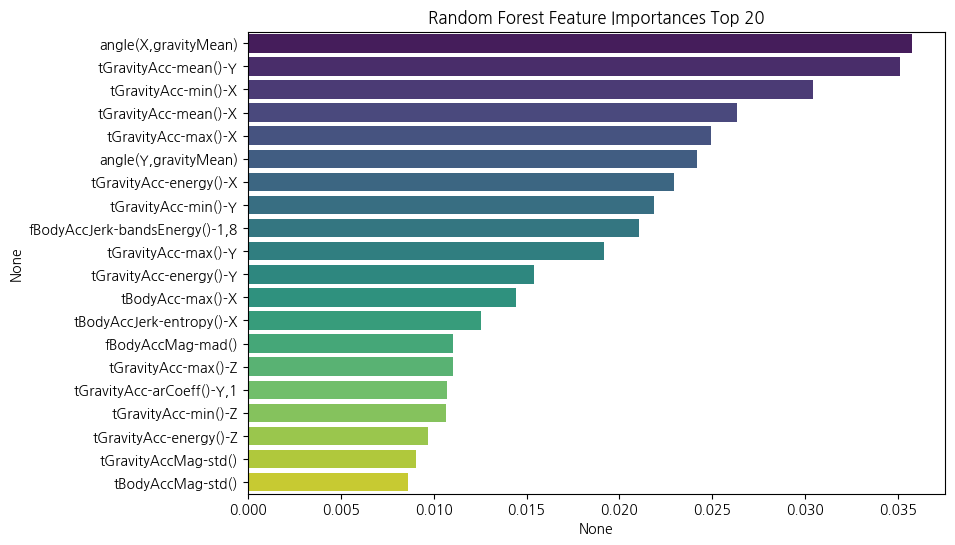

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
# 피처 중요도 시각화 : 중요도가 낮은 피처 제거 -> 과적합 방지, 속도 향상

ftr_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train.columns
)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20] # 피처 중요도 내림차순 정렬, 상위 20개의 피처 선택

plt.figure(figsize=(9, 6))
plt.title('Random Forest Feature Importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index, palette='viridis')
plt.tight_layout
plt.show()

In [31]:
ftr_importances

,0
tBodyAcc-mean()-X,0.000206
tBodyAcc-mean()-Y,0.000249
tBodyAcc-mean()-Z,0.000165
tBodyAcc-std()-X,0.004376
tBodyAcc-std()-Y,0.000427
...,...
"angle(tBodyGyroMean,gravityMean)",0.000486
"angle(tBodyGyroJerkMean,gravityMean)",0.000274
"angle(X,gravityMean)",0.035734
"angle(Y,gravityMean)",0.024171


In [33]:
from sklearn.model_selection import GridSearchCV
# GridSearchCV로 최적 하이퍼파라미터 탐색

params = {
    'n_estimators': [100],
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [8, 12, 18],
    'min_samples_split': [8, 16, 20],
}
rf_clf_gs = RandomForestClassifier(random_state=0, n_jobs=-1) # n_jobs=-1: 모든 CPU 코어 사용 (병렬 처리)
grid_cv = GridSearchCV(rf_clf_gs, param_grid=params, cv=2, n_jobs=-1 )
y_train_reshaped = y_train.values.ravel() # 1차원 배열로 평탄화, GridSearchCV가 y 데이터를 처리하는 방식에 필요
grid_cv.fit(X_train, y_train_reshaped)

print('최적 하이퍼 파라미터:\n',grid_cv.best_params_) # 최적의 하이퍼파라미터 조합
print(f'최고 예측 정확도: {grid_cv.best_score_}')


최적 하이퍼 파라미터:
 {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
최고 예측 정확도: 0.9178454842219804


In [35]:
# 최적 파라미터로 최종 학습
rf_clf1 = RandomForestClassifier(
    n_estimators = 300, # 트리 개수를 300개
    max_depth=10,
    min_samples_leaf=8,
    min_samples_split=8,
    random_state=0
)
y_train_reshaped = y_train.values.ravel()
rf_clf1.fit(X_train, y_train_reshaped)
pred =rf_clf1.predict(X_test)
print(f'최적 파라미터 랜덤 포레스트 정확도: {accuracy_score(y_test, pred)}')

최적 파라미터 랜덤 포레스트 정확도: 0.9165252799457075


### GBM (Gradient Boosting Machine)

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
import time

# 사용자 행동 인식 데이터셋 사용
start_time = time.time()
gb_clf = GradientBoostingClassifier( # 기본값
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=0
)
gb_clf.fit(X_train, y_train_reshaped)
gb_pred=gb_clf.predict(X_test)

print(f'GBM 정확도: {accuracy_score(y_test, gb_pred)}')
print(f'GBM 수행 시간:{time.time() - start_time}') #GBM은 순차 학습 -> 랜덤 포레스트보다 훨씬 느림

GBM 정확도: 0.9379029521547336
GBM 수행 시간:1593.145154953003


In [ ]:
# GBM GridSearchCV (시간이 오래 걸림 - 참고용)
params = {
    'n_estimators': [100, 500],
    'learning_rate': [0.05, 0.1]
}
gb_clf_gs = GradientBoostingClassifier(random_state=0)
grid_cv = GridSearchCV(gb_clf_gs, param_grid=params, cv=2, verbose=1)#verbose=1: 간단한 진행 상황 메시지를 출력
grid_cv.fit(X_train, y_train_reshaped)

print('최적 파라미터:', grid_cv.best_params_)
print(f'최고 정확도: {grid_cv.best_scrore_}')

gb_pred = grid_cv.best_estimator_.predict(X_test) #.best_estimator_속성에서 최적 모델을 가져와서
print(f'테스트텟 정확도: {accuracy_score(y_test.gb_pred)}')